In [99]:
# Import
import matplotlib.pyplot as plt
import numpy as np
from math import dist
from scipy.optimize import minimize, brute
from sklearn.metrics import pairwise_distances
%matplotlib widget

# Les constantes
THETA = np.linspace(0, 2 * np.pi, 100)

# Les variables length et rayon du cylindre
length = 118   
radius = 48.5  

# Les variable L, l, et décalage pour l'ellipse
L = 6
l = 3
décalage = 2

# Les variables du point de vue O et du plan de projection
X0 = np.array([60, 0, 100]) # centre du plan de projection
n = np.array([1, 0, 3]) # vecteur normal au plan
coef_focale = 5
O = X0 + coef_focale*n # point de vue


In [100]:

# faire une Gridsearch avec :
# X[0] = np.linspace(0, 100, 10)
# X[2] = np.linspace(length/2, length, 10)
# n[1] = np.linspace(0, 10, 10)
# coef_focale = np.linspace(0, 10, 10)
# et une mesure de performance adequate
# meilleurs params :  [42.23144507 68.26429752  3.66957402  4.23350573]
# [ 5.589e+01  9.781e+01  1.936e+00  2.133e+01]


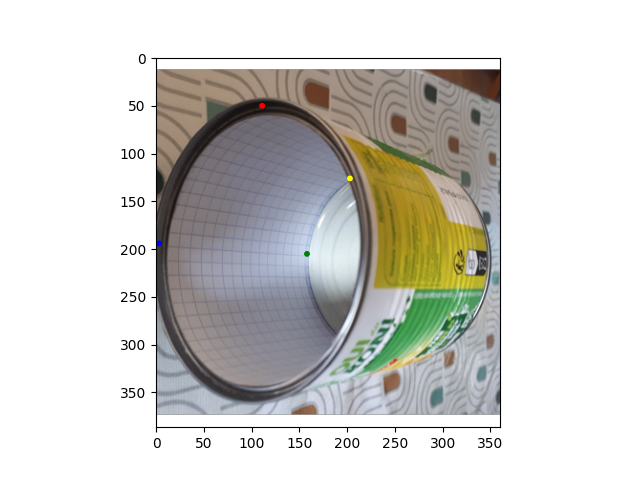

In [101]:
plt.close('all')
# Préparation :
# Récupération de l'image
#img = plt.imread(r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\97_118_5.png")
from PIL import Image
img = Image.open(r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\97_118_5.png")
img = img.rotate(-90)
plt.imshow(img)
# A = np.array([32, 250])
# B = np.array([184, 361])
# C = np.array([188,213])
# D = np.array([113, 165])

A = np.array([111, 50])
B = np.array([3, 194])
C = np.array([158,205])
D = np.array([203, 126])


plt.scatter(np.array([A, B, C, D])[:, 0], np.array([A, B, C, D])[:, 1], s=10, c= ['red', 'blue', 'green', 'yellow'])
plt.show()


In [102]:
# Modélisation :
# Modélisation du cylindre et de la porosité

# Les cercles de base du cylindre
x_circle1 = radius * np.cos(THETA)
y_circle1 = radius * np.sin(THETA)   
z_circle1 = np.full_like(THETA, length/2)  # Le cercle est à z = length/2
x_circle2 = radius * np.cos(THETA)
y_circle2 = radius * np.sin(THETA)
z_circle2 = np.full_like(THETA, -length/2)  # Le cercle est à z = -length/2 

# L'ellipse de porosité
y_ellipse = l * np.sin(THETA)   
z_ellipse = décalage + L * np.cos(THETA)
x_ellipse = np.full_like(y_ellipse, -radius)

# Modélisation du point de vue et du plan de projection
# Le point de vue O est déjà défini dans la partie variables

# Le plan de projection est défini par le point X0 et le vecteur normal n
# Création d'une grille de points (x, y)
xp = np.linspace(-2*radius, 2*radius, 20)
yp = np.linspace(-2*radius, 2*radius, 20)
Xp, Yp = np.meshgrid(xp, yp) # meshgrid est nécessaire pour plot_surface

# Résolution de l'équation du plan pour z : n_x*(x - X0_x) + n_y*(y - X0_y) + n_z*(z - X0_z) = 0
# => z = X0_z - (n_x*(x - X0_x) + n_y*(y - X0_y)) / n_z
Zp = X0[2] - (n[0]*(Xp - X0[0]) + n[1]*(Yp - X0[1])) / n[2]



In [103]:
# Calcul :
# Calcul des projections du cylindre et de l'ellipse sur le plan
# Fonction pour projeter un point P sur le plan défini par le point X0 et le vecteur normal A par rapport à un point de vue O
def projeter_sur_plan(P, n, X0, O):
    '''Projette un point P observé depuis le point d'observation O sur un plan de vision défini par son vecteur normal n et un point X0
    args :
        P (np.array(3)) : les coordonnées du point observé
        n (np.array(3)) : les coordonnées un vecteur normal au plan de vision
        X0 (np.array(3)) : les coordonnées un point appartenant au plan de vision
        O (np.array(3)) : les coordonnées du point d'observation
    return :
        np.array(3) : les coordonnées de la projection du point P sur le plan de vision par homothétie de centre O
        '''
    # Vecteur de P à O
    OP = O - P
    # Intersection de OP avec le plan
    t = np.dot(n, X0 - P) / np.dot(n, OP)
    return P + t * OP

#Projection des deux cercles du cylindre et de l'ellipse sur le plan de projection
cyl_proj1 = np.array([projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0, O) for i in range(len(THETA))])
cyl_proj2 = np.array([projeter_sur_plan(np.array([x_circle2[i], y_circle2[i], z_circle2[i]]), n, X0, O) for i in range(len(THETA))])
ell_proj = np.array([projeter_sur_plan(np.array([x_ellipse[i], y_ellipse[i], z_ellipse[i]]), n, X0, O) for i in range(len(THETA))])

Text(0.5, 0.92, 'Projection du cylindre et de sa porosité sur le plan de vision')

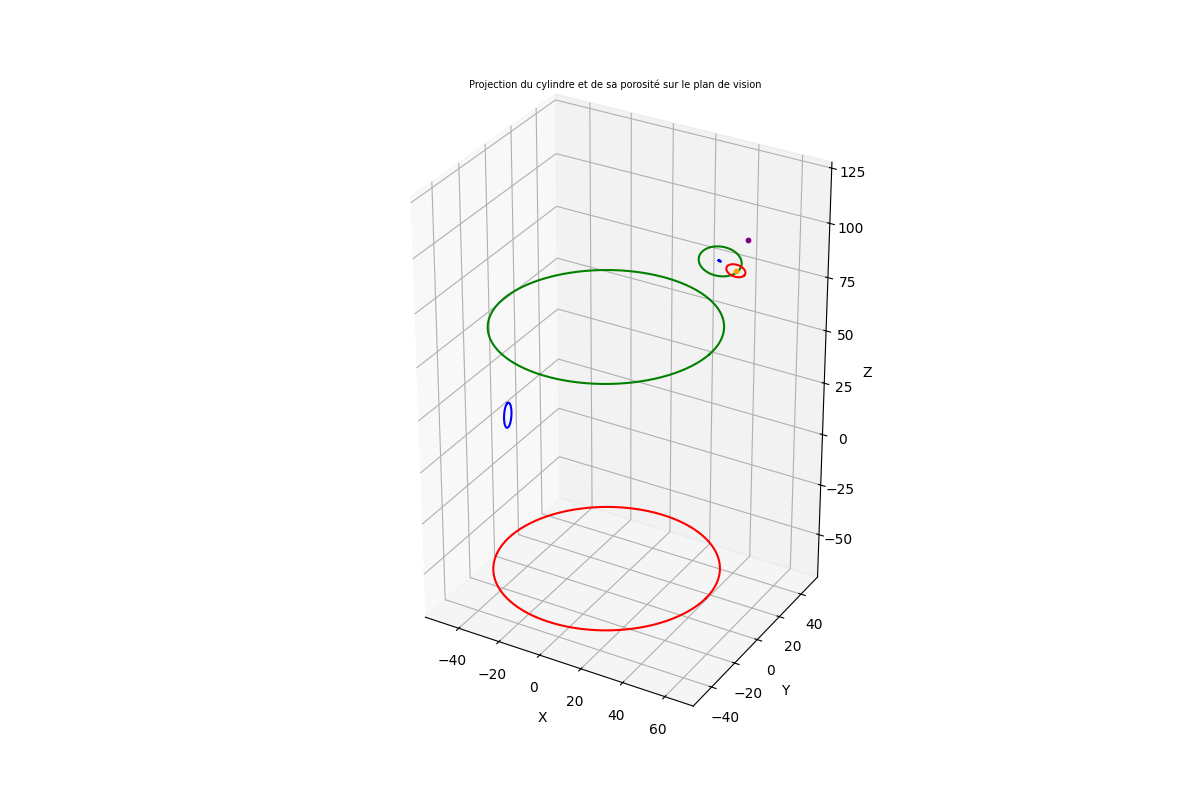

In [104]:
plt.close('all')
# Visualisation :
# Visualisation 3D

# Définition de la figure et des axes 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Tracé des cercles de base du cylindre et de l'ellipse de porosité
ax.plot(x_circle1, y_circle1, z_circle1, color='green', label='Cercle1 de base du cylindre')
ax.plot(x_circle2, y_circle2, z_circle2, color='red', label='Cercle2 de base du cylindre')
ax.plot(x_ellipse, y_ellipse, z_ellipse, color='blue', label='Ellipse de porosité')

# Tracé du point X0
ax.scatter(X0[0], X0[1], X0[2], color='orange', s=10, label='Point X0 (centre du plan de projection)')

# Tracé du plan
#ax.plot_surface(Xp, Yp, Zp, alpha=0.5, color='lightblue', label='Plan')

# Tracé du point de vue O
ax.scatter(O[0], O[1], O[2], color='purple', s=10, label='Point de vue O')

# Tracé de la projection du cylindre et de l'ellipse sur le plan
ax.plot(cyl_proj1[:, 0], cyl_proj1[:, 1], cyl_proj1[:, 2], color='green', label='Projection du cercle1 sur le plan')
ax.plot(cyl_proj2[:, 0], cyl_proj2[:, 1], cyl_proj2[:, 2], color='red', label='Projection du cercle2 sur le plan')
ax.plot(ell_proj[:, 0], ell_proj[:, 1], ell_proj[:, 2], color='blue', label='Projection de l\'ellipse sur le plan')

# Configuration du graphique
ax.set_aspect('equal')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Projection du cylindre et de sa porosité sur le plan de vision', fontsize=7)

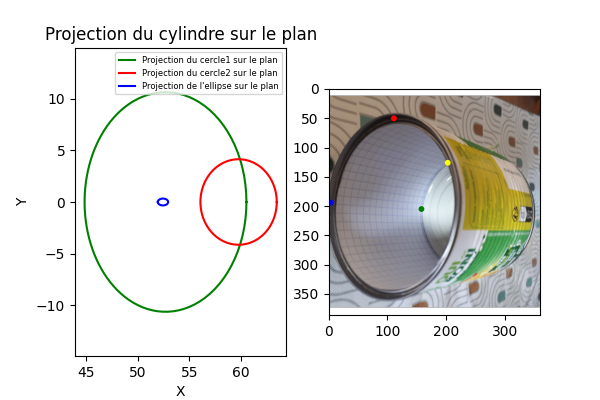

In [105]:
plt.close('all')
# Comparaison de l'image réelle et de la projection du cylindre et de l'ellipse sur le plan
fig, ax = plt.subplots(1, 2, figsize=(6, 4))

# Tracé de la projection du cylindre et de l'ellipse sur le plan
ax[0].plot(cyl_proj1[:, 0], cyl_proj1[:, 1], color='green', label='Projection du cercle1 sur le plan')
ax[0].plot(cyl_proj2[:, 0], cyl_proj2[:, 1], color='red', label='Projection du cercle2 sur le plan')
ax[0].plot(ell_proj[:, 0], ell_proj[:, 1], color='blue', label='Projection de l\'ellipse sur le plan')

ax[0].axis('equal')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title('Projection du cylindre sur le plan')
ax[0].legend(loc='upper right', fontsize='6')
#ax[0].tight_layout()
ax[1].scatter(np.array([A, B, C, D])[:, 0], np.array([A, B, C, D])[:, 1], s=10, c= ['red', 'blue', 'green', 'yellow'])
ax[1].imshow(img)

plt.show()


In [106]:
# Résolution :
# Définition de la métrique
resol_img = plt.imread(r"C:\Users\John\Desktop\jupyter_notebooks\Porosimetre\data\sol.jpg")
plt.imshow(resol_img)
# metric = (delta(a/b)^2 + delta(b/c)^2 + delta(c/a)^2) + delta(d/e)^2
a = dist(A, B)
b = dist(B, C)
c = dist(C, A)
d = dist(C, D)
e = dist(D, A)
f = dist(D, B)


Ap = cyl_proj1[np.argmax(cyl_proj1[:,1])][:2]
Bp = cyl_proj1[np.argmin(cyl_proj1[:,0])][:2]
Cp = cyl_proj2[np.argmin(cyl_proj2[:,0])][:2]


# Calcul de Dp
def point_Dp(pts_1, pts_2):
    '''point_Dp donne les coordonnées du points le plus proche de pts_1 entre deux nuages de points pts_1 et pts_2
        args :
        pts_1 (np.array(n x np.array(2))) : nuage de points 1
        pts_2 (np.array(m x np.array(2))) : nuage de points 2
        return :
        Dp (np.array(2)) : point Dp
    '''
    dist_matrix = pairwise_distances(pts_1, pts_2, metric='euclidean')

    # Cas particulier où il n'y a pas de point d'intersection => il faut disqualifier ce cas
    if np.min(dist_matrix) > 10:
        return np.array([radius, radius])

    idx = np.where(dist_matrix==np.min(dist_matrix))



    if cyl_proj1[idx[0][0]][1] > 0 :
        Dp = cyl_proj1[idx[0][0]]
        return Dp
    else :
        Dp = cyl_proj1[idx[0][0]]
        Dp[1] = -cyl_proj1[idx[0][0]][1]
        return Dp

Dp = point_Dp(cyl_proj1, cyl_proj2)[:2] # car la fonction renvoie un point en 3D !


ap = dist(Ap, Bp)
bp = dist(Bp, Cp)
cp = dist(Cp, Ap)
dp = dist(Cp, Dp)
ep = dist(Dp, Ap)
fp = dist(Dp, Bp)

Dp

array([59.93863851,  4.04812127])

(np.float64(43.911468901194),
 np.float64(64.39922836775054),
 np.float64(-11.699949299270816),
 np.float64(11.699949299270816))

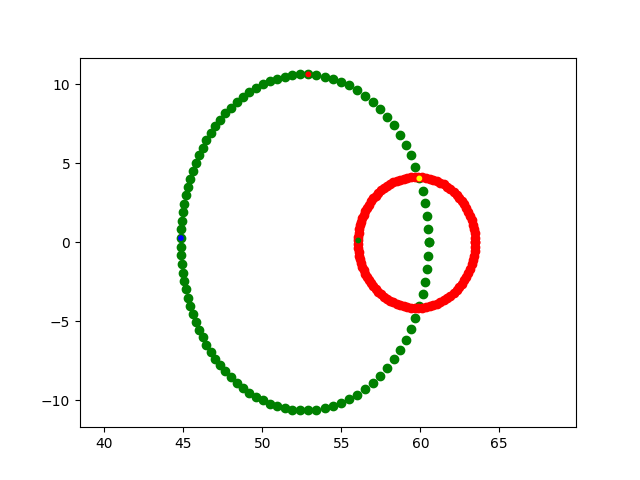

In [107]:
plt.close('all')
# Visualisons les cercles projetés et les points Ap, Bp, Cp, Dp
plt.scatter(cyl_proj1[:,0], cyl_proj1[:,1], c='green')
plt.scatter(cyl_proj2[:,0], cyl_proj2[:,1], c='red')
plt.scatter(np.array([Ap, Bp, Cp, Dp])[:, 0], np.array([Ap, Bp, Cp, Dp])[:, 1], s=10, c= ['red', 'blue', 'green', 'yellow'])
plt.axis('equal')

In [ ]:
# metric = np.square(a/b - ap/bp) + np.square(b/c - bp/cp) + np.square(c/a - cp/ap)+ np.square(d/e - dp/ep)
# ap => Ap => cyl_proj1 => projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0, O) => O => X0 et coef_focale
def metric(params):
    '''Cette fonction retourne la valeur de la métrique à partir d'un tuple des paramètres'''
    X00i, X02i, n2i, coef_focalei = params  # Décomposer le tableau en paramètres
    X0i = np.array([X00i, 0, X02i])
    ni = np.array([1, 0, n2i])
    Oi = X0i + coef_focalei*ni

    # appel des params pour les faire rentrer dans la fonction projeter_sur plan => ...
    #Projection des deux cercles du cylindre et de l'ellipse sur le plan de projection
    cyl_proj1i = np.array([projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0i, Oi) for i in range(len(THETA))])
    cyl_proj2i = np.array([projeter_sur_plan(np.array([x_circle2[i], y_circle2[i], z_circle2[i]]), n, X0i, Oi) for i in range(len(THETA))])
    ell_proji = np.array([projeter_sur_plan(np.array([x_ellipse[i], y_ellipse[i], z_ellipse[i]]), n, X0i, Oi) for i in range(len(THETA))])

    Api = cyl_proj1i[np.argmax(cyl_proj1i[:,1])][:2]
    Bpi = cyl_proj1i[np.argmin(cyl_proj1i[:,0])][:2]
    Cpi = cyl_proj2i[np.argmin(cyl_proj2i[:,0])][:2]

    Dpi = point_Dp(cyl_proj1i, cyl_proj2i)[:2] # car la fonction renvoie un point en 3D !


    api = dist(Api, Bpi)
    bpi = dist(Bpi, Cpi)
    cpi = dist(Cpi, Api)
    dpi = dist(Cpi, Dpi)
    epi = dist(Dpi, Api)
    fpi = dist(Dpi, Bpi)

    if np.any([api == 0, bpi == 0, cpi == 0, dpi == 0, epi == 0, fpi == 0]):
        return 1000
  
    return np.square(a/b - api/bpi) + np.square(b/c - bpi/cpi) + np.square(c/a - cpi/api) + np.square(c/a - cpi/api) + np.square(d/e - dpi/epi) + np.square(a/d - api/dpi) + np.square(f/c - fpi/cpi)

# Recherche de la solution par grille
# params
# X0[0] = np.linspace(0, 100, 10)
# X0[2] = np.linspace(length/2, length, 10)
# n[2] = np.linspace(0, 10, 10)
# coef_focale = np.linspace(0, 10, 10)

# ranges = (
#     np.linspace(0, 100, 10),              # X00
#     np.linspace(length / 2, length, 10),  # X02
#     np.linspace(0, 10, 10),               # n2
#     np.linspace(0, 10, 10)                # coef_focale
# )

result = minimize(metric, [60, 100,  3,  5])
bp = result.x
print("Meilleurs paramètres (X00, X02, n2, coef_focale) :", bp)
print("Valeur minimale de la métrique :", result.fun)


Meilleurs paramètres (X00, X02, n2, coef_focale) : [59.37429423 97.09021282  1.86477729  4.42656136]
Valeur minimale de la métrique : 0.010236987246082999


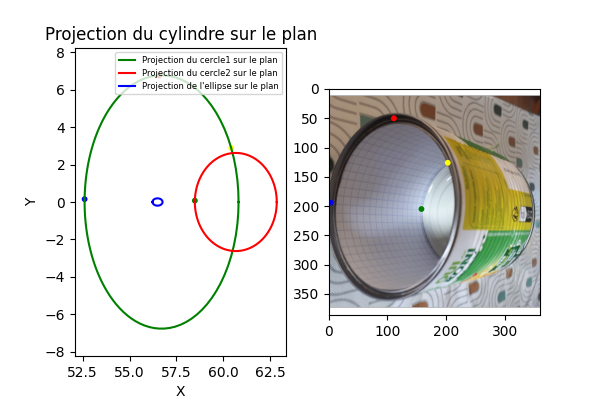

In [111]:
plt.close('all')
# Comparaison de l'image réelle et de la solution
# On met à jour les variables du point de vue O et du plan de projection
# Pour rappel les variables du point de vue O et du plan de projection avant calcul
# X0 = np.array([56, 0, 97]) # centre du plan de projection
# n = np.array([1, 0, 2])    # vecteur normal au plan
# coef_focale = 21
# O = X0 + coef_focale*n     # point de vue

# params
# X0[0] = np.linspace(0, 100, 10)
# X0[2] = np.linspace(length/2, length, 10)
# n[2] = np.linspace(0, 10, 10)
# coef_focale = np.linspace(0, 10, 10)

X0 = np.array([bp[0], 0, bp[1]]) # centre du plan de projection
n = np.array([1, 0, bp[2]]) # vecteur normal au plan
coef_focale = bp[3]
O = X0 + coef_focale*n # point de vue

# Projection des deux cercles du cylindre et de l'ellipse sur le plan de projection
cyl_proj1 = np.array([projeter_sur_plan(np.array([x_circle1[i], y_circle1[i], z_circle1[i]]), n, X0, O) for i in range(len(THETA))])
cyl_proj2 = np.array([projeter_sur_plan(np.array([x_circle2[i], y_circle2[i], z_circle2[i]]), n, X0, O) for i in range(len(THETA))])
ell_proj = np.array([projeter_sur_plan(np.array([x_ellipse[i], y_ellipse[i], z_ellipse[i]]), n, X0, O) for i in range(len(THETA))])

# Calcul des points caractéistiques
Ap = cyl_proj1[np.argmax(cyl_proj1[:,1])][:2]
Bp = cyl_proj1[np.argmin(cyl_proj1[:,0])][:2]
Cp = cyl_proj2[np.argmin(cyl_proj2[:,0])][:2]
Dp = point_Dp(cyl_proj1, cyl_proj2)[:2]

# Comparaison de l'image réelle et de la projection du cylindre et de l'ellipse sur le plan
fif, ax = plt.subplots(1, 2, figsize=(6, 4))

# Tracé de la projection du cylindre et de l'ellipse sur le plan
ax[0].scatter(np.array([Ap, Bp, Cp, Dp])[:, 0], np.array([Ap, Bp, Cp, Dp])[:, 1], s=10, c= ['red', 'blue', 'green', 'yellow'])
ax[0].plot(cyl_proj1[:, 0], cyl_proj1[:, 1], color='green', label='Projection du cercle1 sur le plan')
ax[0].plot(cyl_proj2[:, 0], cyl_proj2[:, 1], color='red', label='Projection du cercle2 sur le plan')
ax[0].plot(ell_proj[:, 0], ell_proj[:, 1], color='blue', label='Projection de l\'ellipse sur le plan')


ax[0].axis('equal')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')
ax[0].set_title('Projection du cylindre sur le plan')
ax[0].legend(loc='upper right', fontsize='6')
#ax[0].tight_layout()
ax[1].scatter(np.array([A, B, C, D])[:, 0], np.array([A, B, C, D])[:, 1], s=10, c= ['red', 'blue', 'green', 'yellow'])
ax[1].imshow(img)


In [121]:
Bx = B - Bp
bx = Bx[0]
bx

np.float64(-49.60171856628899)

In [123]:
B

array([  3, 194])

In [122]:
Bp[0] + bx

np.float64(3.0)

In [ ]:
#du coup bouger cyl_proj et les points projetés de +x = bx et inverser en y les points D et A avant/pendant metric si utilisation de la métrique A-Ap...